# 第 11 章 CellTypist 自动注释

## 学习目标

学习自动注释，并用标记基因和手工结果检查模型预测。

## 为什么做与怎样做

从 counts 层构造每细胞 10,000 counts 的 log1p 输入，加载本地 High/Low 模型。分别保存单细胞预测、多数投票标签及与标签对应的置信度。

前置章节：10。运行前请完成项目环境准备。


In [1]:
from __future__ import annotations
from pathlib import Path
import os
import sys
ROOT = Path(os.environ.get("SC_COURSE_ROOT", Path.cwd())).resolve()
while not (ROOT / "config/course.json").is_file() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "config/course.json").is_file():
    raise RuntimeError("请从课程目录或其 notebooks/exercises 目录运行。")
os.environ["CELLTYPIST_FOLDER"] = str(ROOT / ".runtime/celltypist")
os.environ["MPLCONFIGDIR"] = str(ROOT / ".runtime/matplotlib")
sys.path.insert(0, str(ROOT / "tools"))
from course_runtime import start_chapter, marker_sets, scaled_view
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation
ctx = start_chapter("11")
adata = ctx.load_input()


第 11 章：CellTypist 自动注释
结果目录：results/11_celltypist/20260915T075936_a73aa2


读取检查点：results/10_differential_expression/20260915T075105_46d0d8/checkpoint.h5ad
17,041 个细胞 × 23,427 个基因


## 11.1 自动注释

In [2]:
# 功能说明：更新图形输出目录。
# 运行目的：为自动注释部分设置单独的图片保存路径。

# 设置输出目录
sc.settings.figdir = ctx.figures

与手动注释数据方法不同，如下所述，生成的注释质量可能参差不齐。因此，重要的是将这些方法视为注释过程的起点而不是终点。
如前所述，自动生成的注释质量可能会有所不同。更具体地说，注释的质量取决于：
1) 分类器训练数据的质量。如果训练数据没有得到很好的注释或注释分辨率很低，分类器也会这样做。同样，如果训练数据和/或其注释有噪声，分类器可能表现不佳。<br>
2) 您自己的数据与分类器训练数据的相似性。例如，如果分类器是在 drop-seq 单细胞数据集上训练的，而您的数据是 10X 单核而不是单细胞 drop-seq，这可能会降低注释的质量。在包含多种数据集的跨数据集图谱上训练的分类器可能比在单个数据集上训练的分类器提供更稳健和质量更好的注释。一个例子是在人类肺细胞图谱 （参考文献：anno:Sikkema2023） 上训练的 CellTypist（一种将在下面更广泛讨论的自动注释方法）分类器，其中包括 14 个不同的肺数据集。该模型在新肺数据上的表现可能优于在单个肺数据集上训练的模型。

上述几点强调了使用分类器的可能缺点，具体取决于训练数据和模型类型。尽管如此，使用预训练分类器注释数据有几个重要的优点。首先，这是一种快速简便的注释数据的方法。注释不需要下载也不需要预处理训练数据，有时只涉及将数据上传到在线网页。其次，这些方法不依赖于将数据划分为簇，就像手动注释那样。第三，预训练分类器使您能够直接利用先前研究的知识和信息，例如高质量的注释。最后，使用此类分类器有助于协调整个领域的细胞类型定义，从而为就这些定义达成全领域共识扫清道路。

值得注意的是，到目前为止讨论的方法仅使用了数据中检测到的一小部分基因：通常每个细胞类型仅使用 1 到 ~10 个标记基因。另一种方法是使用将更大的基因集（数千个或更多）作为输入的分类器，从而更多地利用 scRNA-seq 数据的广度。此类分类器在先前注释的数据集或图谱上进行训练。这些示例包括 CellTypist （参考文献：anno:Conde2022）（另请参见 https://www.celltypist.org，可以将数据上传到门户以获得自动细胞注释）和 Clustifyr （参考文献：anno:Fu2020）。

让我们在我们的数据上试用 CellTypist。根据 CellTypist 教程 (https://www.celltypist.org/tutorials;https://www.celltypist.org/models)，我们知道我们需要准备数据，以便将计数归一化为每个细胞 10,000 个计数，然后进行 log1p 转换：

In [3]:
# 从 counts 构造模型要求的输入；主分析对象的 log1p 层保持原含义。
adata_celltypist = adata.copy()
adata_celltypist.X = adata_celltypist.layers["counts"].copy()
sc.pp.normalize_total(adata_celltypist, target_sum=10**4)
sc.pp.log1p(adata_celltypist)
# CellTypist 接受稀疏 AnnData；模型内部仅对所需特征做缩放。

本课程使用随包提供的免疫细胞 CellTypist 模型，可直接从 model 目录加载。

In [4]:
# 功能说明：导入 CellTypist 库。
# 运行目的：加载自动注释所需的工具包。
# 详细代码解析：
# - `import celltypist`: 导入主包。
# - `from celltypist import models`: 导入模型管理模块。

# import sys
# !{sys.executable} -m pip install celltypist

import celltypist
from celltypist import models

/data/home/heqingchuan/workdir/19_方超老师合作_单细胞_gpt6/sc_RNA/sc_RNA_basic_course/.envs/sc_rna/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [5]:
print(ROOT / "model")

/data/home/heqingchuan/workdir/19_方超老师合作_单细胞_gpt6/sc_RNA/sc_RNA_basic_course/model


In [6]:
model_paths = [ROOT / "model/Immune_All_High.pkl", ROOT / "model/Immune_All_Low.pkl"]
for path in model_paths:
    if not path.is_file():
        raise FileNotFoundError(f"缺少课程模型：{path}")
    print(path.name, path.stat().st_size, "bytes")

Immune_All_High.pkl 1070426 bytes
Immune_All_Low.pkl 2824990 bytes


让我们尝试 `Immune_All_Low` 和 `Immune_All_High` 模型（这些分别在更精细的注释级别（低）和更粗略的级别（高）注释免疫细胞类型）：

In [7]:
# 功能说明：加载下载好的 CellTypist 模型。
# 运行目的：将模型文件读入内存，准备进行预测。
# 详细代码解析：
# 1. `models.Model.load(...)`
#    - 加载指定的模型文件。
#    - `model_low`: 精细注释模型。
#    - `model_high`: 粗略注释模型。

model_low = models.Model.load(model=str(ROOT / "model" / "Immune_All_Low.pkl"))
model_high = models.Model.load(model=str(ROOT / "model" / "Immune_All_High.pkl"))

对于其中的每一个，我们可以查看它包含哪些细胞类型，看看是否包含骨髓细胞类型：

In [8]:
# 功能说明：查看粗略模型包含的细胞类型。
# 运行目的：了解该模型能识别哪些细胞类型，确认是否包含我们感兴趣的类型。
# 详细代码解析：
# 1. `model_high.cell_types`
#    - 打印模型中定义的所有细胞类型标签列表。

model_high.cell_types

array(['B cells', 'B-cell lineage', 'Cycling cells', 'DC', 'DC precursor',
       'Double-negative thymocytes', 'Double-positive thymocytes', 'ETP',
       'Early MK', 'Endothelial cells', 'Epithelial cells',
       'Erythrocytes', 'Erythroid', 'Fibroblasts', 'Granulocytes',
       'HSC/MPP', 'ILC', 'ILC precursor', 'MNP', 'Macrophages',
       'Mast cells', 'Megakaryocyte precursor',
       'Megakaryocytes/platelets', 'Mono-mac', 'Monocyte precursor',
       'Monocytes', 'Myelocytes', 'Plasma cells', 'Promyelocytes',
       'T cells', 'pDC', 'pDC precursor'], dtype=object)

In [9]:
# 功能说明：查看精细模型包含的细胞类型。
# 运行目的：了解精细模型能识别哪些具体的细胞亚型。

model_low.cell_types

array(['Age-associated B cells', 'Alveolar macrophages', 'B cells',
       'CD16+ NK cells', 'CD16- NK cells', 'CD8a/a', 'CD8a/b(entry)',
       'CMP', 'CRTAM+ gamma-delta T cells', 'Classical monocytes',
       'Cycling B cells', 'Cycling DCs', 'Cycling NK cells',
       'Cycling T cells', 'Cycling gamma-delta T cells',
       'Cycling monocytes', 'DC', 'DC precursor', 'DC1', 'DC2', 'DC3',
       'Double-negative thymocytes', 'Double-positive thymocytes', 'ELP',
       'ETP', 'Early MK', 'Early erythroid', 'Early lymphoid/T lymphoid',
       'Endothelial cells', 'Epithelial cells', 'Erythrocytes',
       'Erythrophagocytic macrophages', 'Fibroblasts',
       'Follicular B cells', 'Follicular helper T cells', 'GMP',
       'Germinal center B cells', 'Granulocytes', 'HSC/MPP',
       'Hofbauer cells', 'ILC', 'ILC precursor', 'ILC1', 'ILC2', 'ILC3',
       'Intermediate macrophages', 'Intestinal macrophages',
       'Kidney-resident macrophages', 'Kupffer cells',
       'Large pre-B cell

看起来这些模型包括许多不同的免疫细胞类型祖细胞！
现在让我们运行模型。首先是粗略的那个：

In [10]:
# 功能说明：使用粗略模型进行细胞类型预测。
# 运行目的：自动注释数据中的细胞类型（粗略级别）。
# 详细代码解析：
# 1. `celltypist.annotate(...)`
#    - `adata_celltypist`: 预处理好的数据对象。
#    - `model=model_high`: 使用粗略模型。
#    - `majority_voting=True`:
#      - 启用多数投票机制。
#      - 结合细胞周围邻居的预测结果来修正当前细胞的预测，通常能提高准确性并减少噪声。

predictions_high = celltypist.annotate(
    adata_celltypist, model=model_high, majority_voting=True
)

🔬 Input data has 17041 cells and 23427 genes


🔗 Matching reference genes in the model


🧬 5852 features used for prediction


⚖️ Scaling input data


🖋️ Predicting labels


✅ Prediction done!


👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it


⛓️ Over-clustering input data with resolution set to 10


🗳️ Majority voting the predictions


✅ Majority voting done!


将预测转换为 adata 以获得完整输出...

In [11]:
# 功能说明：将预测结果转换为 AnnData 对象。
# 运行目的：方便后续处理和提取结果。
# 详细代码解析：
# 1. `.to_adata()`
#    - 将 `AnnotationResult` 对象转换为 `AnnData` 对象。
#    - 预测结果（标签、概率等）存储在返回对象的 `.obs` 中。

predictions_high_adata = predictions_high.to_adata(insert_conf_by="majority_voting")

...并将结果复制到我们原始的 AnnData 对象：

In [12]:
# 功能说明：将粗略注释结果复制回原始 AnnData 对象。
# 运行目的：将自动注释结果整合到主分析对象中，以便进行可视化和对比。
# 详细代码解析：
# 1. `adata.obs["celltypist_cell_label_coarse"]`
#    - 存储多数投票后的预测标签 (`"majority_voting"`)。
# 2. `adata.obs["celltypist_conf_score_coarse"]`
#    - 存储预测的置信度分数 (`"conf_score"`)。

adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "conf_score"
]
adata.obs["celltypist_predicted_label_coarse"] = predictions_high.predicted_labels["predicted_labels"].reindex(adata.obs_names)


现在对更精细的注释做同样的事情：

In [13]:
# 功能说明：使用精细模型进行细胞类型预测。
# 运行目的：自动注释数据中的细胞类型（精细级别）。
# 详细代码解析：
# 1. `celltypist.annotate(...)`
#    - 使用 `model_low` 进行预测。

predictions_low = celltypist.annotate(
    adata_celltypist, model=model_low, majority_voting=True
)

🔬 Input data has 17041 cells and 23427 genes


🔗 Matching reference genes in the model


🧬 5852 features used for prediction


⚖️ Scaling input data


🖋️ Predicting labels


✅ Prediction done!


👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it


⛓️ Over-clustering input data with resolution set to 10


🗳️ Majority voting the predictions


✅ Majority voting done!


In [14]:
# 功能说明：将精细预测结果转换为 AnnData 对象。

predictions_low_adata = predictions_low.to_adata(insert_conf_by="majority_voting")

In [15]:
# 功能说明：将精细注释结果复制回原始 AnnData 对象。
# 运行目的：整合精细注释结果。

adata.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "conf_score"
]
adata.obs["celltypist_predicted_label_fine"] = predictions_low.predicted_labels["predicted_labels"].reindex(adata.obs_names)


现在绘图：

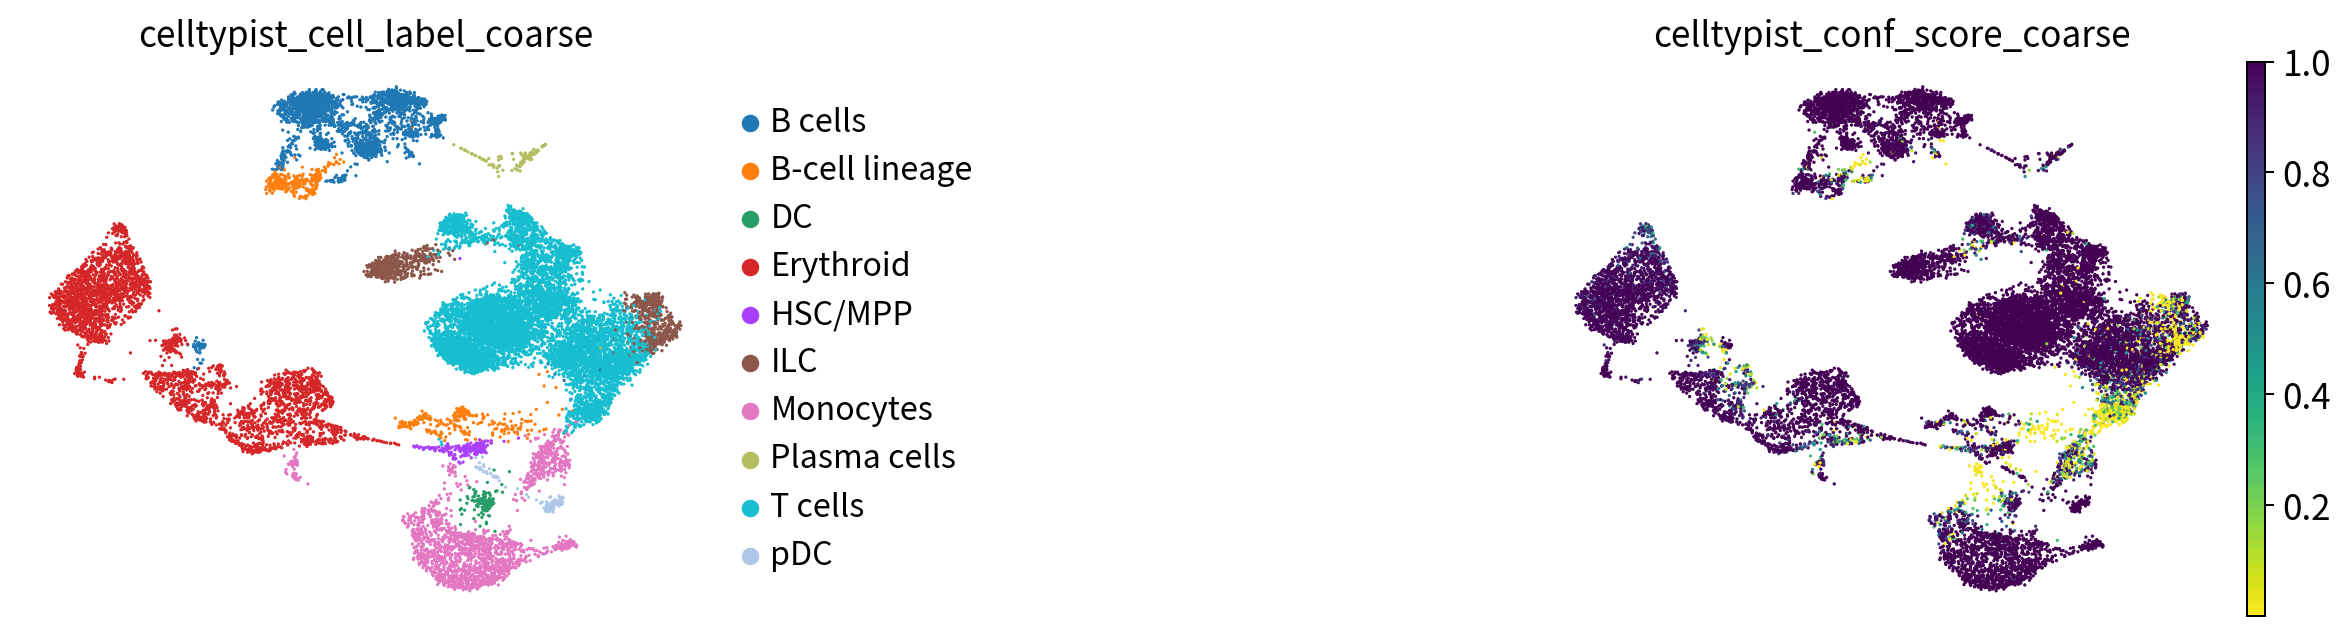

In [16]:
# 功能说明：在 UMAP 上可视化粗略注释结果和置信度。
# 运行目的：直观评估自动注释的效果和可靠性。
# 详细代码解析：
# 1. `sc.pl.umap(...)`
#    - `color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"]`:
#      - 左图：展示粗略分类标签。
#      - 右图：展示分类的置信度分数。颜色越深/亮表示置信度越高。
#    - `wspace=1`: 增加子图间距。

sc.pl.umap(
    adata,
    color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"],
    frameon=False,
    sort_order=False,
    wspace=1,
    save="_11_303.pdf"
)

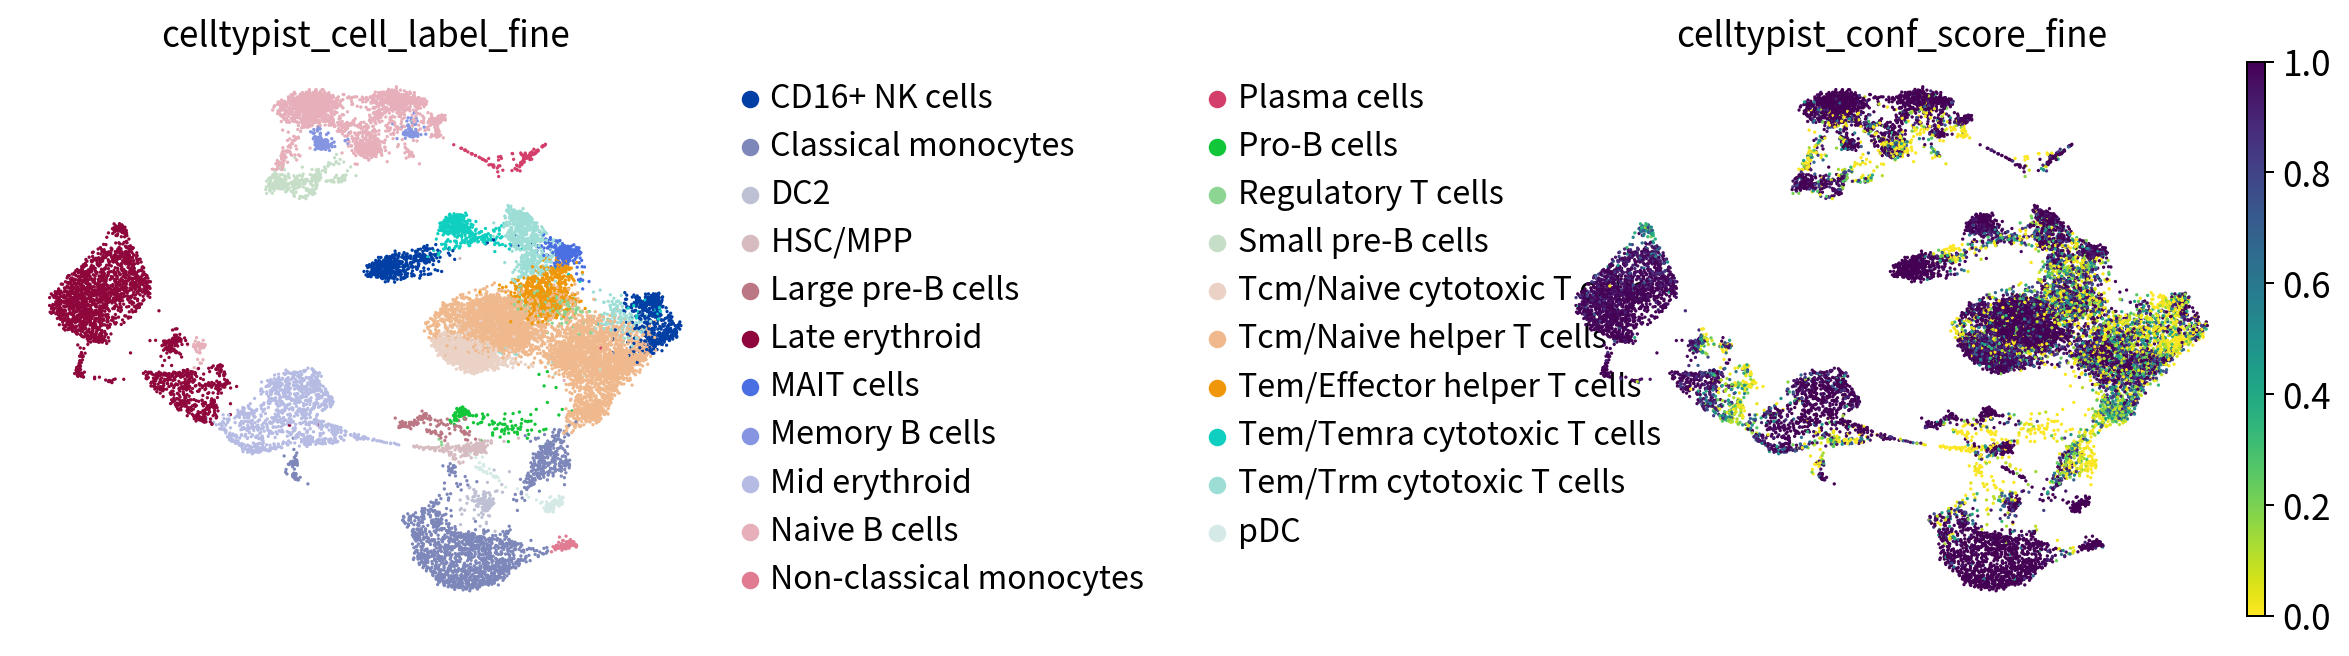

In [17]:
# 功能说明：在 UMAP 上可视化精细注释结果和置信度。
# 运行目的：评估精细注释的效果。
# 详细代码解析：
# 1. `sc.pl.umap(...)`
#    - `color=["celltypist_cell_label_fine", "celltypist_conf_score_fine"]`: 展示精细标签和置信度。

sc.pl.umap(
    adata,
    color=["celltypist_cell_label_fine", "celltypist_conf_score_fine"],
    frameon=False,
    sort_order=False,
    wspace=1,
    save="_11_304.pdf"
)

了解这些注释质量的一种方法是查看观察到的细胞类型相似性是否符合我们的预期：

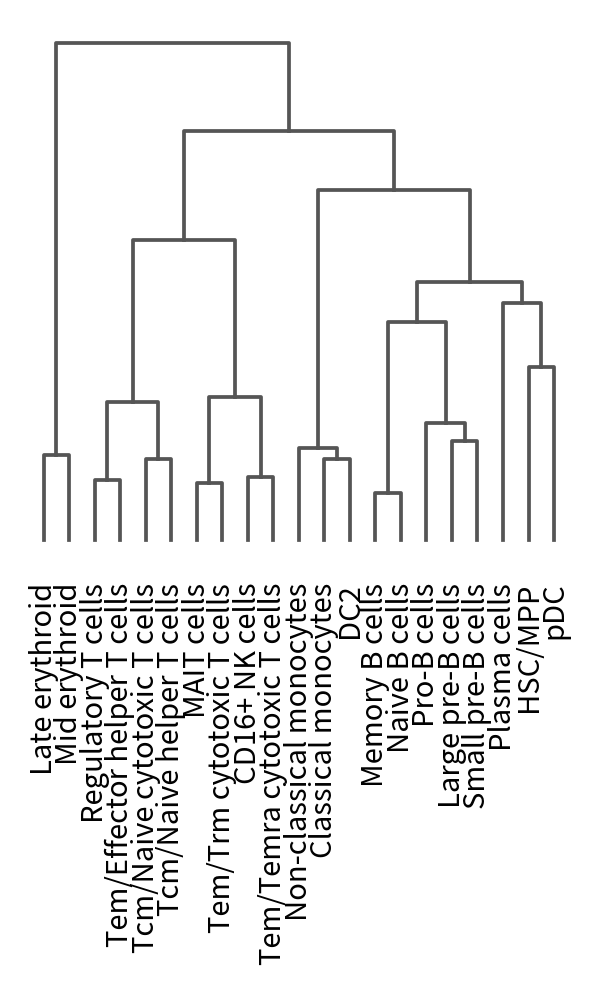

<Axes: >

In [18]:
# 功能说明：绘制树状图（Dendrogram），展示预测细胞类型之间的转录组相似性。
# 运行目的：检查自动注释的细胞类型在转录组水平上是否合理聚类。例如，不同类型的 T 细胞应该聚在一起。如果出现生物学上不合理的聚类（如 T 细胞与红细胞聚在一起），可能提示注释错误。
# 详细代码解析：
# 1. `sc.pl.dendrogram(adata, groupby="celltypist_cell_label_fine")`
#    - `sc.pl.dendrogram`: 绘制树状图。
#    - `groupby="celltypist_cell_label_fine"`: 计算给定分组（这里是精细注释标签）的平均表达谱，并基于相关性构建树状图。

sc.pl.dendrogram(adata, groupby="celltypist_cell_label_fine", save="_11_306.pdf")

观察同类或相关细胞群是否具有相似的表达模式。树状图是转录组相似性的概括，不能单独证明发育谱系或断定标签正确。

现在让我们看看我们早期的手动注释：

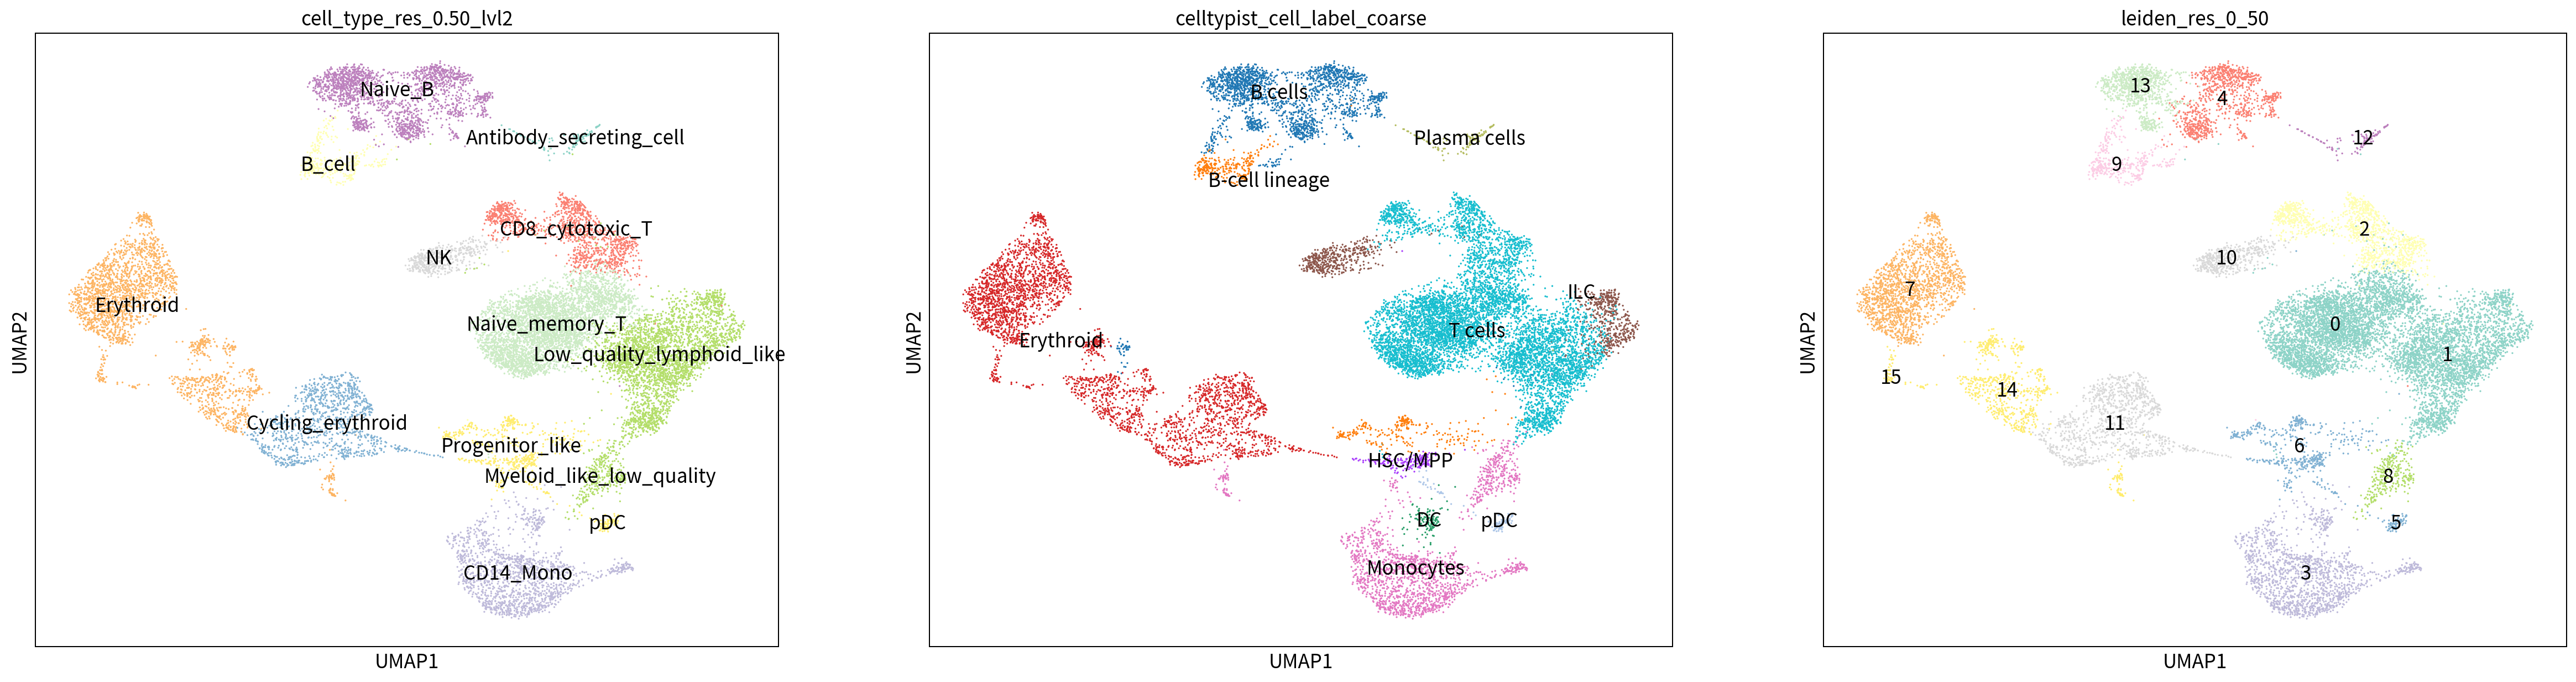

In [19]:
# 功能说明：在 UMAP 上对比手动注释和自动注释结果。
# 运行目的：直观比较两种注释方法的一致性和差异。
# 详细代码解析：
# 1. `color=[...]`:
#    - `cell_type_res_0.50_lvl2`: 手动二级注释。
#    - `celltypist_cell_label_coarse`: 自动粗略注释。
#    - `leiden_res_0_50`: 聚类结果。

# 查看注释结果
with rc_context({"figure.figsize": (10, 8)}):
    sc.pl.umap(
            adata,
            color=["cell_type_res_0.50_lvl2","celltypist_cell_label_coarse","leiden_res_0_50" ],
            legend_loc="on data",
            save="_11_309.pdf",
            )

比较手工注释与自动标签的一致性，并结合置信度和标记基因解释不一致区域。两者都不是独立的真实标签；一致并不等同于已验证准确。

下面选择精细模型多数投票标签置信度中位数最低的聚类，检查该簇内部的粗、细预测组成。

In [20]:
focus_cluster = adata.obs.groupby("leiden_res_0_50", observed=True)["celltypist_conf_score_fine"].median().idxmin()
print("本次检查的聚类：", focus_cluster)
# 功能说明：查看特定簇（Cluster 4）在自动注释（粗略）中的构成。
# 运行目的：定量分析手动聚类与自动注释的对应关系。
# 详细代码解析：
# 1. `pd.crosstab(...)`
#    - 创建交叉表：行是 Leiden 聚类，列是 CellTypist 粗略标签。
# 2. `.loc[focus_cluster, :]`
#    - 提取 Cluster 4 的数据。
# 3. `.sort_values(ascending=False)`
#    - 排序，查看 Cluster 4 主要被预测为什么类型。

pd.crosstab(adata.obs.leiden_res_0_50, adata.obs.celltypist_cell_label_coarse).loc[
    focus_cluster, :
].sort_values(ascending=False)

本次检查的聚类： 8


celltypist_cell_label_coarse
Monocytes         298
B cells             0
B-cell lineage      0
DC                  0
HSC/MPP             0
Erythroid           0
ILC                 0
Plasma cells        0
T cells             0
pDC                 0
Name: 8, dtype: int64

In [21]:
# 功能说明：查看特定簇（Cluster 4）在自动注释（精细）中的构成。
# 运行目的：更细致地分析 Cluster 4 的成分。

pd.crosstab(adata.obs.leiden_res_0_50, adata.obs.celltypist_cell_label_fine).loc[
    focus_cluster, :
].sort_values(ascending=False)

celltypist_cell_label_fine
Classical monocytes            298
CD16+ NK cells                   0
DC2                              0
HSC/MPP                          0
Large pre-B cells                0
Late erythroid                   0
MAIT cells                       0
Memory B cells                   0
Mid erythroid                    0
Naive B cells                    0
Non-classical monocytes          0
Plasma cells                     0
Pro-B cells                      0
Regulatory T cells               0
Small pre-B cells                0
Tcm/Naive cytotoxic T cells      0
Tcm/Naive helper T cells         0
Tem/Effector helper T cells      0
Tem/Temra cytotoxic T cells      0
Tem/Trm cytotoxic T cells        0
pDC                              0
Name: 8, dtype: int64

自动注释为进一步审阅提供起点。对不一致或证据不足的标签保留不确定性，并利用已知标记基因、样本组成和模型适用范围继续检查。

## 保存本章结果

保存表格、参数摘要和可供后续章节读取的数据。

In [22]:
ctx.table("celltypist_annotations", adata.obs)
ctx.table("manual_vs_auto_coarse", pd.crosstab(adata.obs["cell_type_res_0.50_lvl1"], adata.obs["celltypist_cell_label_coarse"]))
ctx.table("manual_vs_auto_fine", pd.crosstab(adata.obs["cell_type_res_0.50_lvl2"], adata.obs["celltypist_cell_label_fine"]))
ctx.table("confidence_by_cluster", adata.obs.groupby("leiden_res_0_50", observed=True)[["celltypist_conf_score_coarse", "celltypist_conf_score_fine"]].agg(["median", "mean", "min"]))
ctx.finish(adata, {"coarse_labels": adata.obs["celltypist_cell_label_coarse"].value_counts().to_dict(), "fine_labels": adata.obs["celltypist_cell_label_fine"].value_counts().to_dict(), "median_confidence_coarse": float(adata.obs["celltypist_conf_score_coarse"].median()), "median_confidence_fine": float(adata.obs["celltypist_conf_score_fine"].median())})

本章计算完成。请阅读本次图表和表格，再更新本章解读。


## 结果阅读与思考

请打开本次结果目录中的 summary.json、tables 和 figures。将目的、方法、结果和解释写入本章报告源稿，再更新 Word。

思考题：自动注释与手工注释不一致时，应继续检查哪些证据？

运行与报告操作见课程根目录的 99_运行与AI协作指南.md。